<a href="https://colab.research.google.com/github/fedhere/DSPS_FBianco/blob/master/labs/kmans_by_WillowFortino.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pylab as pl
import sklearn.cluster
import time
import os
import urllib
%pylab inline
pl.style.use('ggplot')


Populating the interactive namespace from numpy and matplotlib


## generating random data:
## 2 gaussian distributions, differnt means, different stsndard deviations


9.8 6.5 1.1 1.4 


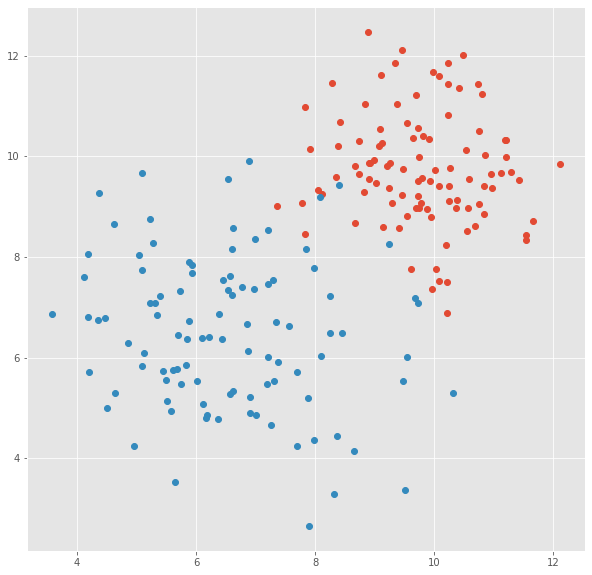

In [ ]:

pl.figure(figsize = (10,10))
# seed for reporducibility
np.random.seed(1999)
#k1s, k1m = np.random.rand()*5, random.rand()*10 
##k2s, k2m = np.random.rand()*2.5, random.rand()*10
#
k1m, k2m, k1s, k2s = 9.8, 6.5, 1.1, 1.4
k1 = (k1s * np.random.randn(2, 100) + k1m).T
k2 = (k2s * np.random.randn(2, 100) + k2m).T
print ("{:.2} {:.2} {:.2} {:.2} ".format(k1m, k2m, k1s, k2s))
pl.plot(k1[:,0], k1[:,1], 'o')
pl.plot(k2[:,0], k2[:,1], 'o');



## choose 2 random starting points: random locations within the distribution


In [ ]:
k1.shape, k2.shape

((100, 2), (100, 2))

In [ ]:
extent = np.min(k1), np.max(k2)
extent

(6.879560004637106, 10.313598203433411)

In [ ]:
rng = np.random.RandomState(193)
import scipy as sp
import scipy.stats

extent = np.min(k1), np.max(k2)

centers0 = sp.stats.uniform.rvs(loc=extent[0], scale=np.diff(extent), size=(2, 2))

In [ ]:
centers0[0]

array([7.88716514, 7.26400682])

9.8 6.5 1.1 1.4 


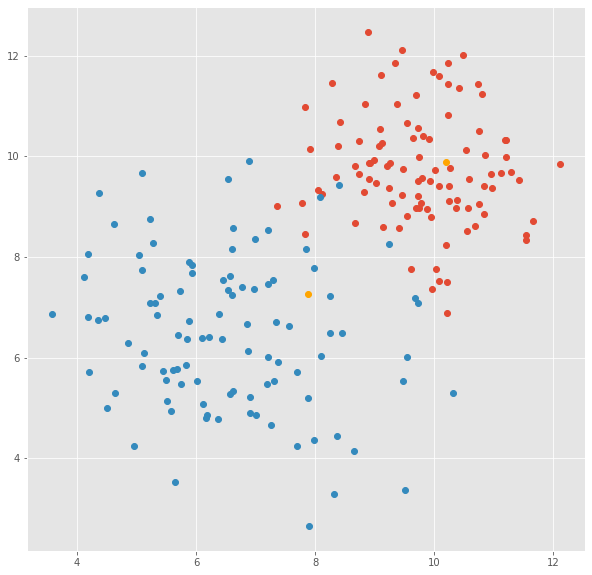

In [ ]:

pl.figure(figsize = (10,10))
# seed for reporducibility

print ("{:.2} {:.2} {:.2} {:.2} ".format(k1m, k2m, k1s, k2s))
pl.plot(k1[:,0], k1[:,1], 'o')
pl.plot(k2[:,0], k2[:,1], 'o');
pl.plot(centers0[0, 0], centers0[0, 1], c="orange", ls="None", marker="o")
pl.plot(centers0[1, 0], centers0[1, 1], c="orange", ls="None", marker="o")


In [ ]:
def L2(center, point):
    """
    center and point are 2D, one for each feature
    """
    L2 = np.sqrt(np.sum((center - point)**2, axis=0))
    return L2

c0 = np.array([0, 0])
p0 = np.array([1, 1])

L2(c0, p0)

1.4142135623730951

In [ ]:
L2(centers0[0], centers0[1])

3.4876300148966064

In [ ]:
k_arr = np.concatenate((k1, k2))
k_arr.shape

(200, 2)

In [ ]:
centers0[0].shape

(2,)

In [ ]:
L2(centers0[0], k_arr.T)

ValueError: ignored

In [ ]:
c0 = centers0[0]
c0 = np.reshape(c0, (2, 1))

c1 = centers0[1]
c1 = np.reshape(c1, (2, 1))

In [ ]:
c0.shape, c1.shape

((2, 1), (2, 1))

In [ ]:
dist0 = L2(c0, k_arr.T)
dist1 = L2(c1, k_arr.T)

In [ ]:
ind = dist0 > dist1
ind

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True, False,  True,  True,  True,  True,
        True,  True,  True, False,  True,  True, False,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True, False,
        True,  True,  True, False,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
       False,  True, False,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True, False,  True,  True,  True,  True,
        True,  True,  True,  True, False, False,  True,  True,  True,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,

In [ ]:
grp1 = k_arr[ind]
grp2 = k_arr[~ind]

In [ ]:
grp1.shape

(90, 2)

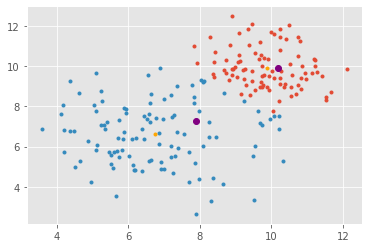

In [ ]:
pl.plot(grp1[:, 0], grp1[:, 1], ".")
pl.plot(grp2[:, 0], grp2[:, 1], ".")
mean1 = grp1.mean(axis=0)
mean2 = grp2.m ean(axis=0)
pl.plot(mean1[0], mean1[1], ".", c="orange")
pl.plot(mean2[0], mean2[1], ".", c="orange")
pl.plot(centers0[0, 0], centers0[0, 1], c="purple", ls="None", marker="o")
pl.plot(centers0[1, 0], centers0[1, 1], c="purple", ls="None", marker="o")

In [ ]:
while np.abs((mean1 - center0[0])) > 1e-5